In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

In [26]:
df = pd.read_csv("data/german_credit.csv")

df["target"] = df["default"].map({
    1: 0,
    2: 1
})

df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,age,installment_plan,housing,existing_credits,job,dependents,telephone,foreign_worker,default,target
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,67,none,own,2,skilled employee,1,yes,yes,1,0
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,22,none,own,1,skilled employee,1,none,yes,2,1
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,49,none,own,1,unskilled resident,2,none,yes,1,0
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,45,none,for free,1,skilled employee,2,none,yes,1,0
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,53,none,for free,2,skilled employee,2,none,yes,2,1


In [27]:
X = df.drop(
    columns=["default", "target"]
)

y = df["target"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [31]:
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

model.fit(
    X_train,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


d:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance_df.head()

,Feature,Coefficient
0,cat__checking_balance_1 - 200 DM,0.125570
1,cat__checking_balance_< 0 DM,0.510765
2,cat__checking_balance_> 200 DM,-0.227098
3,cat__checking_balance_unknown,-1.050227
4,cat__credit_history_critical,-0.917570


In [33]:
top_risk = importance_df.sort_values(
    by="Coefficient",
    ascending=False
).head(15)

top_risk

,Feature,Coefficient
13,cat__purpose_education,0.846607
1,cat__checking_balance_< 0 DM,0.510765
21,cat__savings_balance_< 100 DM,0.486186
6,cat__credit_history_fully repaid,0.482517
39,cat__property_unknown/none,0.440175
10,cat__purpose_car (new),0.359660
29,cat__personal_status_divorced male,0.354962
56,remainder__installment_rate,0.344359
17,cat__purpose_repairs,0.295241
45,cat__housing_rent,0.291385


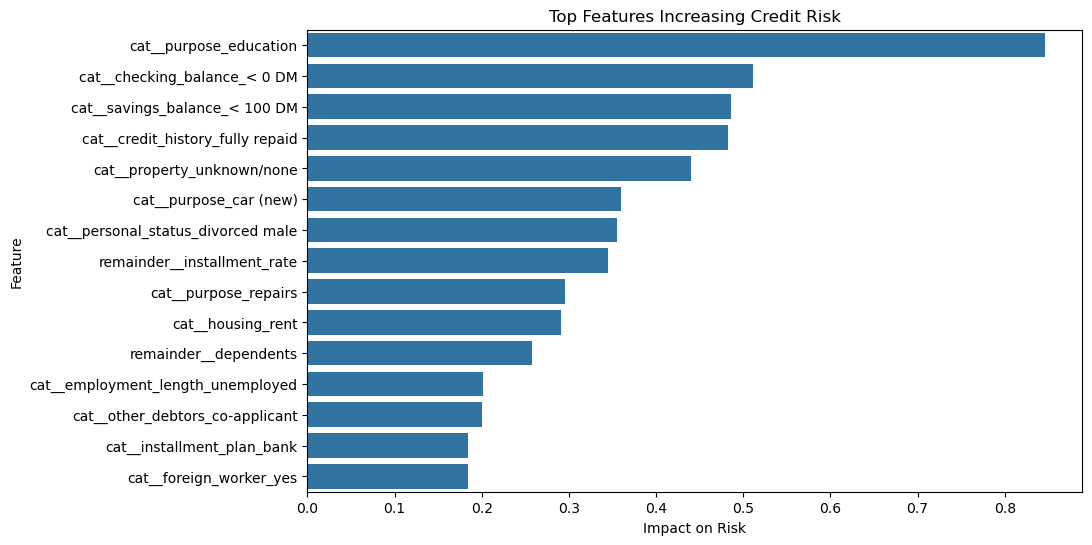

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_risk,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Features Increasing Credit Risk"
)

plt.xlabel(
    "Impact on Risk"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [35]:
top_safe = importance_df.sort_values(
    by="Coefficient",
    ascending=True
).head(15)

top_safe

,Feature,Coefficient
3,cat__checking_balance_unknown,-1.050227
11,cat__purpose_car (used),-0.920449
4,cat__credit_history_critical,-0.917570
52,cat__foreign_worker_no,-0.824701
43,cat__housing_for free,-0.663246
32,cat__personal_status_single male,-0.657060
41,cat__installment_plan_none,-0.653243
34,cat__other_debtors_guarantor,-0.652099
26,cat__employment_length_4 - 7 yrs,-0.628836
22,cat__savings_balance_> 1000 DM,-0.621939


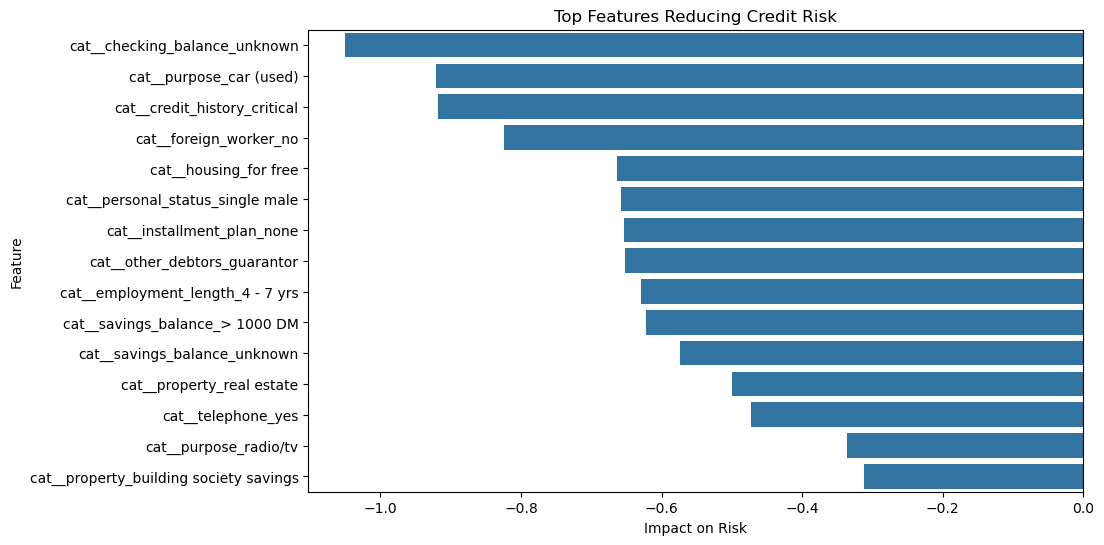

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_safe,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Top Features Reducing Credit Risk"
)

plt.xlabel(
    "Impact on Risk"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [37]:
risk_summary = importance_df.copy()

risk_summary["Abs_Coefficient"] = (
    risk_summary["Coefficient"]
    .abs()
)

risk_summary = risk_summary.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

risk_summary.head(20)

,Feature,Coefficient,Abs_Coefficient
3,cat__checking_balance_unknown,-1.050227,1.050227
11,cat__purpose_car (used),-0.920449,0.920449
4,cat__credit_history_critical,-0.917570,0.917570
13,cat__purpose_education,0.846607,0.846607
52,cat__foreign_worker_no,-0.824701,0.824701
43,cat__housing_for free,-0.663246,0.663246
32,cat__personal_status_single male,-0.657060,0.657060
41,cat__installment_plan_none,-0.653243,0.653243
34,cat__other_debtors_guarantor,-0.652099,0.652099
26,cat__employment_length_4 - 7 yrs,-0.628836,0.628836


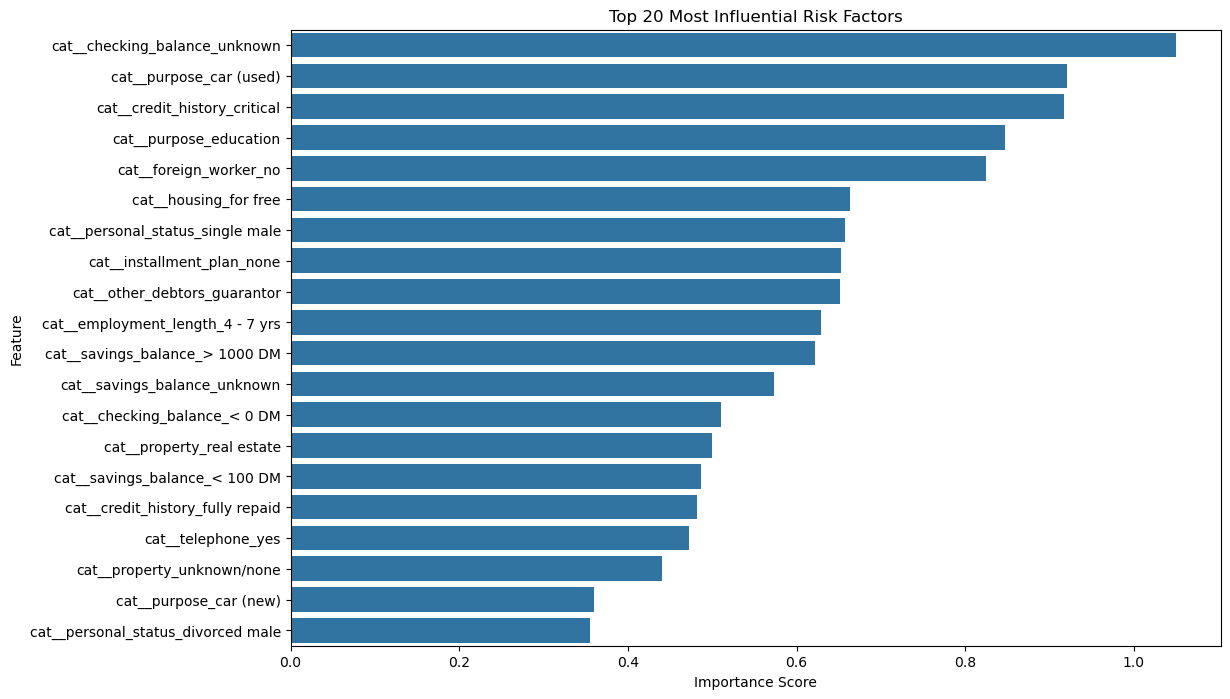

In [38]:
top20 = risk_summary.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Abs_Coefficient",
    y="Feature"
)

plt.title(
    "Top 20 Most Influential Risk Factors"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [39]:
print("""
Business Interpretation

The model identifies several key drivers that influence credit risk.

High positive coefficients indicate factors associated with higher default risk.

High negative coefficients indicate factors associated with lower default risk.

These insights can support lending officers in understanding
which applicant characteristics contribute most to risk assessment.

The explainability layer improves transparency and supports
more informed credit approval decisions.
""")


Business Interpretation

The model identifies several key drivers that influence credit risk.

High positive coefficients indicate factors associated with higher default risk.

High negative coefficients indicate factors associated with lower default risk.

These insights can support lending officers in understanding
which applicant characteristics contribute most to risk assessment.

The explainability layer improves transparency and supports
more informed credit approval decisions.



In [40]:
y_prob = model.predict_proba(
    X_test
)[:,1]

risk_df = X_test.copy()

risk_df["Probability_Default"] = y_prob

risk_df["Expected_Loss"] = (
    risk_df["amount"]
    *
    risk_df["Probability_Default"]
)

risk_df[
    [
        "amount",
        "Probability_Default",
        "Expected_Loss"
    ]
].head()

,amount,Probability_Default,Expected_Loss
30,1913,0.237172,453.709335
128,1860,0.098476,183.165353
289,1024,0.600357,614.765790
216,3104,0.542562,1684.112156
966,2520,0.152697,384.797566


In [41]:
risk_df.sort_values(
    by="Expected_Loss",
    ascending=False
)[
    [
        "amount",
        "Probability_Default",
        "Expected_Loss"
    ]
].head(10)

,amount,Probability_Default,Expected_Loss
915,18424,0.824355,15187.907716
818,15857,0.938285,14878.378026
917,14896,0.810239,12069.319499
887,15672,0.688513,10790.369210
832,11816,0.905754,10702.388215
395,11760,0.830178,9762.888339
431,11328,0.685155,7761.438926
953,10974,0.643176,7058.211645
522,7119,0.878502,6254.053404
938,6288,0.897860,5645.742624


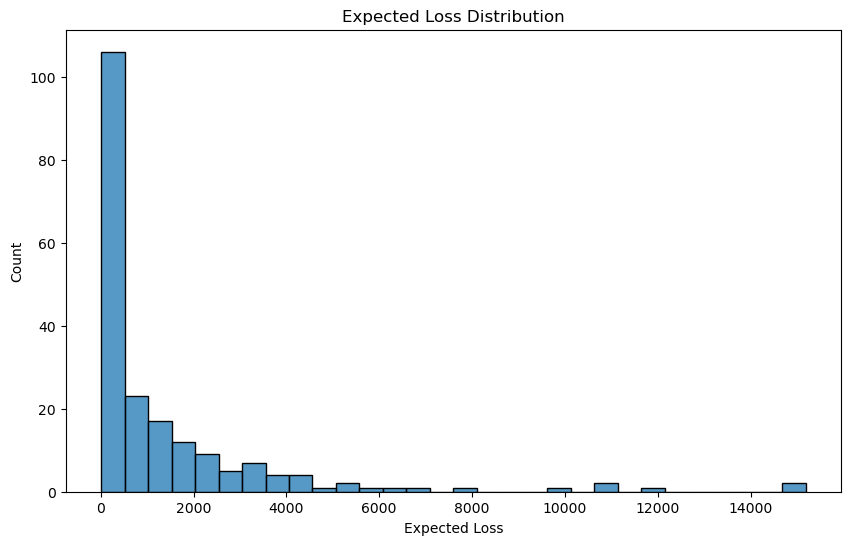

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(
    risk_df["Expected_Loss"],
    bins=30
)

plt.title(
    "Expected Loss Distribution"
)

plt.xlabel(
    "Expected Loss"
)

plt.show()

In [43]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/credit_risk_model.pkl")

['models/credit_risk_model.pkl']

In [44]:
joblib.dump(
    model,
    "models/credit_risk_model.pkl"
)

['models/credit_risk_model.pkl']

In [45]:
loaded_model = joblib.load(
    "models/credit_risk_model.pkl"
)

print("Model loaded successfully")

Model loaded successfully
